### Extracting Keystrokes

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import os
import wave
from scipy.io import wavfile
import soundfile as sf

def RecordingKeyStrokesIsolator(rawAudioSignal: np.array, sampleRate: int, FFTWindowSize: int, scan: int, before, after, threshold, outPutDir, cleanFilePath, show=False):
    strokes = []
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(rawAudioSignal, sr=sampleRate)
        plt.title("Original Audio Signal")
        plt.show()
        plt.close()
    

    fft = librosa.stft(rawAudioSignal, n_fft=FFTWindowSize, hop_length=scan)
   
    energy = np.abs(np.sum(fft, axis=0)).astype(float)
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(energy)
        plt.title("Energy Peaks")
        plt.show()
        plt.close()

    threshed = energy > threshold
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(threshed.astype(float))
        plt.title(f"Energy Peaks above the threshold value {threshold}")
        plt.show()
        plt.close()

    peaks = np.where(threshed == True)[0]
    peak_count = len(peaks)

    prev_end = sampleRate * 0.1 * (-1)

    for i in range(peak_count):
        this_peak = peaks[i]
        timestamp = (this_peak * scan) + FFTWindowSize // 2
        if timestamp > prev_end + (0.1 * sampleRate):
            keystroke = rawAudioSignal[timestamp - before:timestamp + after]
            strokes.append(torch.tensor(keystroke)[None, :])

            if not os.path.exists(outPutDir):
                os.mkdir(outPutDir)       
            filename = f"{outPutDir}{len(strokes)}.wav"
            sf.write(
                filename,
                keystroke,
                sampleRate,
                subtype='PCM_16'
            )
            if show:
                plt.figure(figsize=(7, 2))
                librosa.display.waveshow(keystroke, sr=sampleRate)
                plt.title(f"Keystroke {len(strokes)}")
                plt.show()
                plt.close()
        
        prev_end = timestamp + after

    print(f"Isolated {len(strokes)} keystrokes → saved to {os.path.abspath(outPutDir)}")

    silenceSamples = int(sampleRate * 200 / 1000)
    silence = np.zeros(silenceSamples, dtype=np.float32)
    clips = []
    for i, stroke in enumerate(strokes):
        clip = stroke.squeeze(0).numpy()
        clips.append(clip)
        if i < len(strokes) - 1: # No trailing silence after last keystroke
            clips.append(silence) #Adding the pause after each key strokes
    combined = np.concatenate(clips, axis=0)
    sf.write(
        cleanFilePath,
        combined,
        sampleRate,
        subtype='PCM_16'
    )
    print(f"Combined WAV saved → {cleanFilePath} ({len(combined)/sampleRate:.2f}s)")        
    return strokes    

Sample rate: 48000 Hz
Audio data shape: (1019904,)
Audio data type: int16


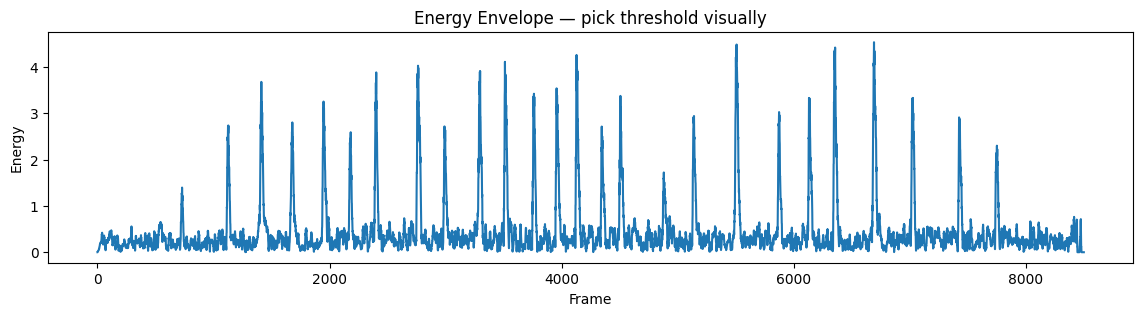

Min:     0.0
Max:     4.53377628326416
Mean:    0.4604794180729334
Median:  0.27295029163360596
Std:     0.6464595636841858


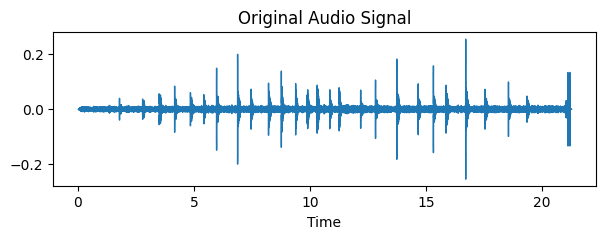

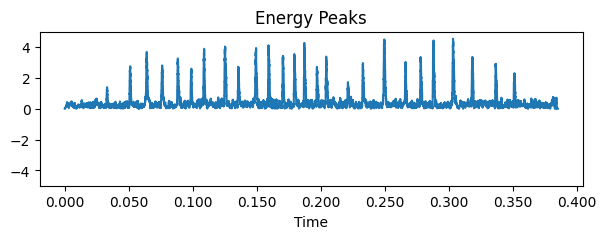

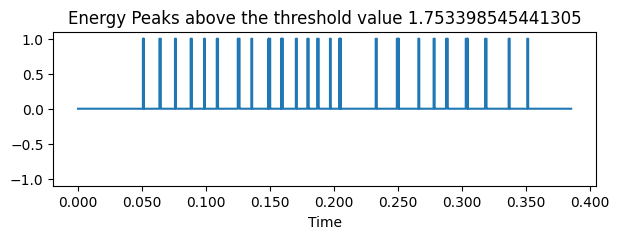

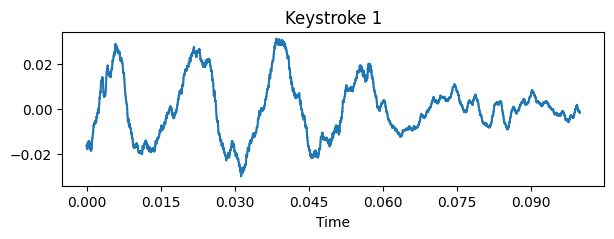

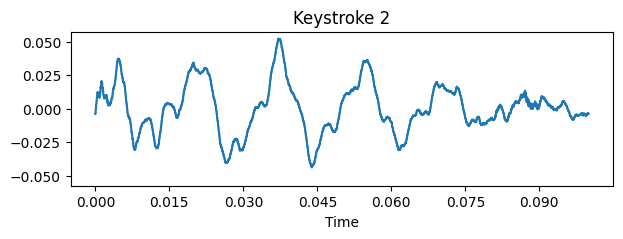

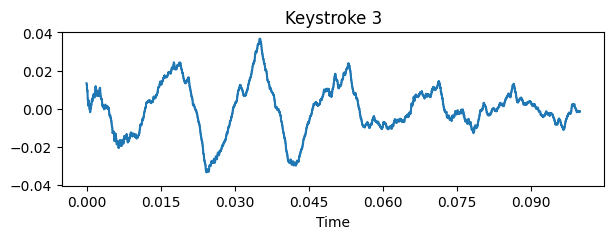

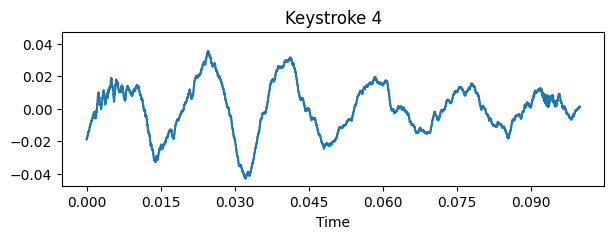

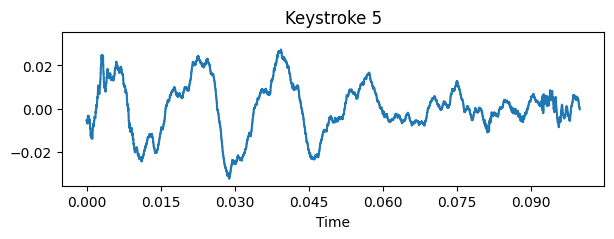

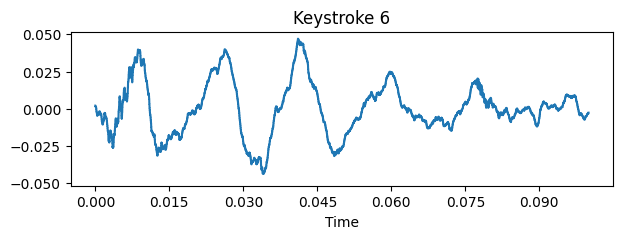

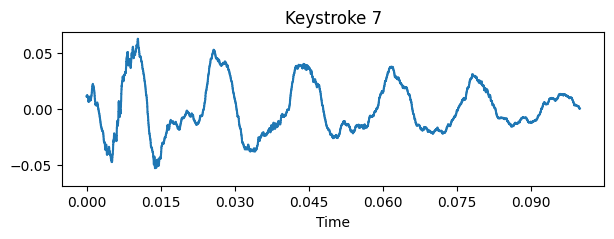

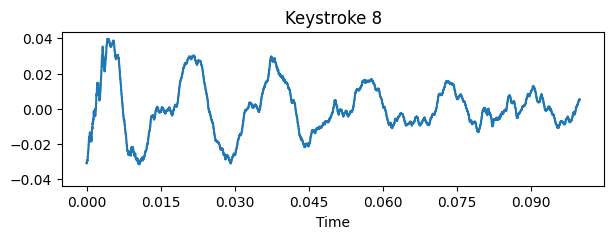

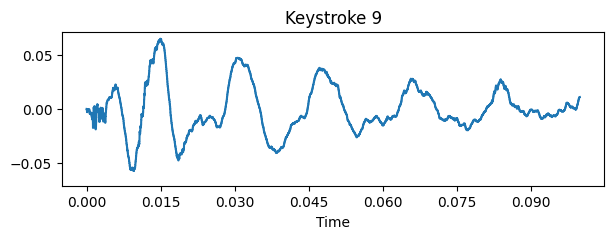

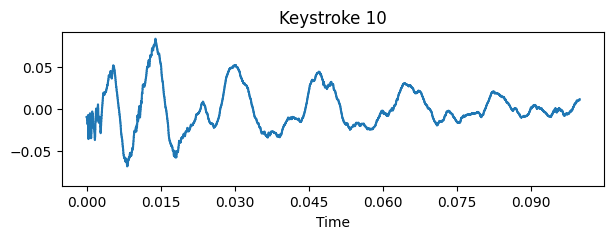

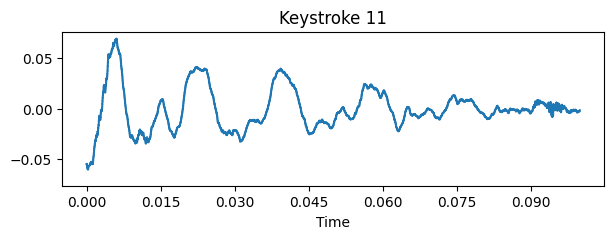

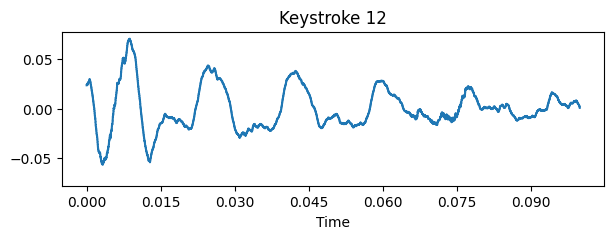

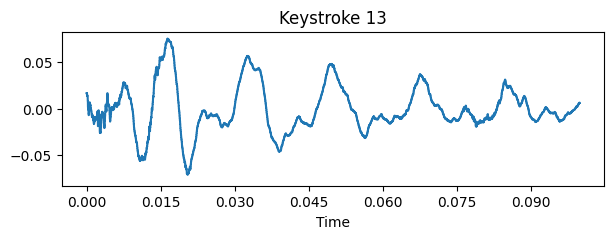

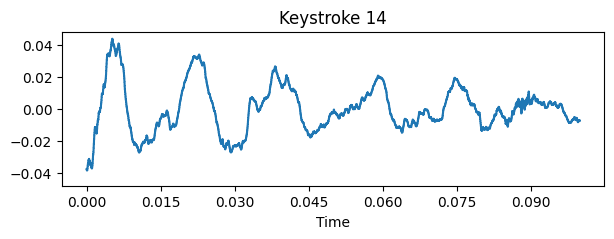

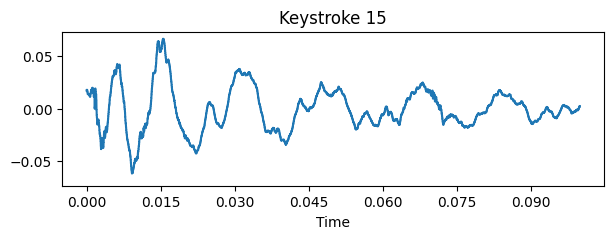

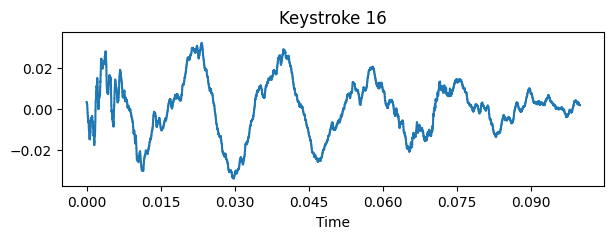

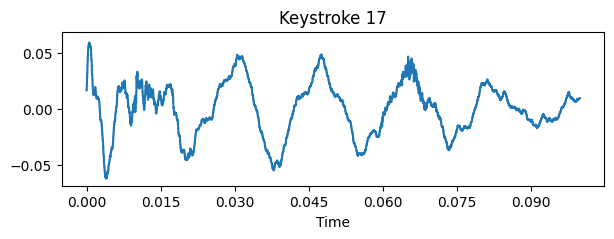

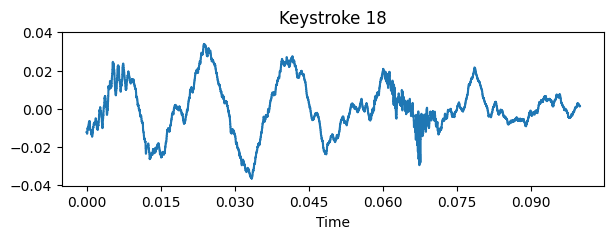

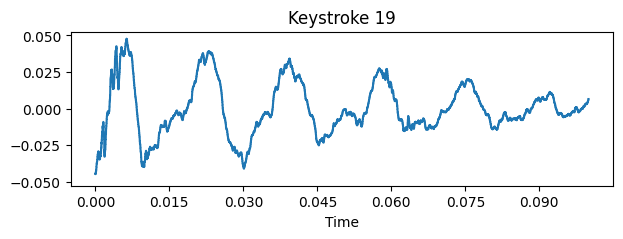

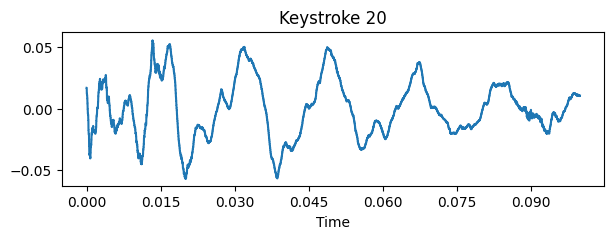

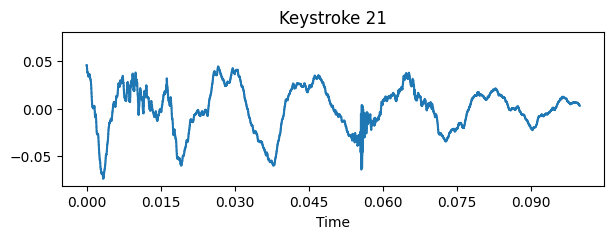

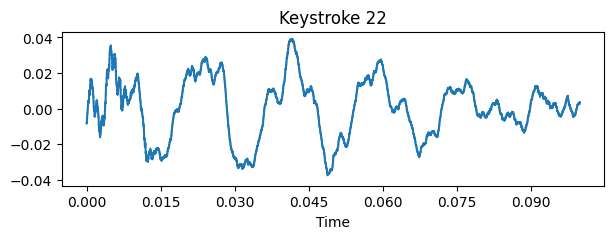

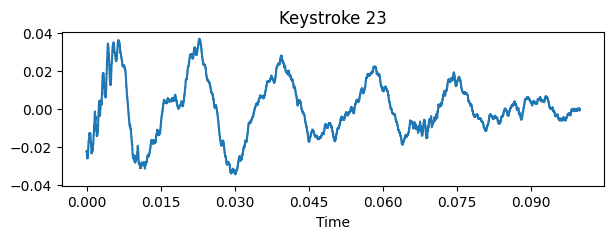

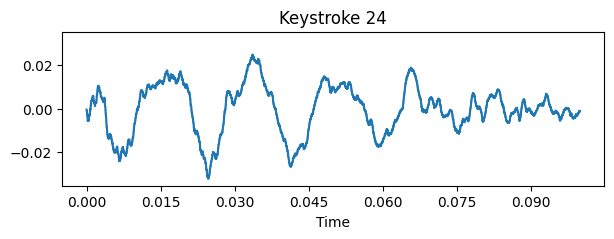

Isolated 24 keystrokes → saved to /Users/davidnguyen/PycharmProjects/MachineLearningProjects/Keyboard -ASCA/InferencePhrase/a-zPhone
Combined WAV saved → a-zPhone-clean.wav (7.00s)


[tensor([[-0.0164, -0.0164, -0.0166,  ..., -0.0016, -0.0016, -0.0017]]),
 tensor([[-0.0039, -0.0037, -0.0022,  ..., -0.0037, -0.0039, -0.0040]]),
 tensor([[ 0.0134,  0.0133,  0.0124,  ..., -0.0015, -0.0015, -0.0013]]),
 tensor([[-0.0190, -0.0186, -0.0183,  ...,  0.0012,  0.0014,  0.0014]]),
 tensor([[-5.4018e-03, -5.7375e-03, -5.6764e-03,  ...,  1.2207e-04,
          -6.1037e-05, -2.7467e-04]]),
 tensor([[ 0.0021,  0.0018,  0.0013,  ..., -0.0031, -0.0030, -0.0027]]),
 tensor([[ 1.1139e-02,  1.0804e-02,  1.0926e-02,  ...,  1.2207e-04,
          -3.0519e-05,  1.2207e-04]]),
 tensor([[-0.0309, -0.0310, -0.0305,  ...,  0.0055,  0.0054,  0.0052]]),
 tensor([[-0.0002, -0.0004, -0.0014,  ...,  0.0107,  0.0108,  0.0108]]),
 tensor([[-0.0100, -0.0098, -0.0099,  ...,  0.0110,  0.0110,  0.0111]]),
 tensor([[-0.0548, -0.0544, -0.0547,  ..., -0.0020, -0.0017, -0.0016]]),
 tensor([[0.0237, 0.0238, 0.0240,  ..., 0.0018, 0.0014, 0.0010]]),
 tensor([[0.0167, 0.0165, 0.0168,  ..., 0.0062, 0.0064, 0.0062

In [2]:
INFERENCE_AUDIO = "a-zPhone.wav"
INFERENCE_DIR = f"./{INFERENCE_AUDIO.split('.')[0]}/"



sampleRate, audioData = wavfile.read(INFERENCE_AUDIO)

print(f"Sample rate: {sampleRate} Hz")
print(f"Audio data shape: {audioData.shape}")
print(f"Audio data type: {audioData.dtype}")

"""Convert audio signal to float32 - Reason because stft only accept float32 dtype"""
audioData = audioData.astype(np.float32) / np.iinfo(np.int16).max

"""Convert stereo to mono"""
if audioData.ndim == 2:
    audioData = np.mean(audioData, axis=1)

"""Assume a keystroke sound is 5-20ms long"""
FFTWindowSize = int(sampleRate * 0.02)
scan = FFTWindowSize // 8 # <- Smaller sliding to capture as much keystrokes as possible, tradeoff longer execution and more computing resources exhausted

before = int(sampleRate * 0.02)   # 20ms
after  = int(sampleRate * 0.08)   # 80ms

# Step 1: Plot the energy envelope and visually inspect
fft = librosa.stft(audioData, n_fft=FFTWindowSize, hop_length=scan)
energy = np.abs(np.sum(fft, axis=0)).astype(float)

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title("Energy Envelope — pick threshold visually")
plt.ylabel("Energy")
plt.xlabel("Frame")
plt.show()
plt.close()

# Step 2: Check the distribution
print("Min:    ", energy.min())
print("Max:    ", energy.max())
print("Mean:   ", energy.mean())
print("Median: ", np.median(energy))
print("Std:    ", energy.std())

# Step 3: A good starting threshold is usually:
threshold = energy.mean() + 2 * energy.std()


RecordingKeyStrokesIsolator(audioData, sampleRate, FFTWindowSize, scan, before, after, threshold, INFERENCE_DIR , f"{INFERENCE_AUDIO.split('.')[0]}-clean.wav", show=True)

In [3]:
from sklearn.preprocessing import LabelEncoder




ALL_CLASSES = list("abcdefghijklmnopqrstuvwxyz0123456789")  # 36 classes
label_encoder = LabelEncoder()
label_encoder.fit(ALL_CLASSES)

logitLabels = {}
for char in ALL_CLASSES:
    logitLabels[str(label_encoder.transform([char])[0])] = char

print(logitLabels)

{'10': 'a', '11': 'b', '12': 'c', '13': 'd', '14': 'e', '15': 'f', '16': 'g', '17': 'h', '18': 'i', '19': 'j', '20': 'k', '21': 'l', '22': 'm', '23': 'n', '24': 'o', '25': 'p', '26': 'q', '27': 'r', '28': 's', '29': 't', '30': 'u', '31': 'v', '32': 'w', '33': 'x', '34': 'y', '35': 'z', '0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9'}


### LOADING MODELS

In [4]:
import torch
import torch.nn as nn

class CoAtNet(nn.Module):
    def __init__(self, num_classes=36, dropout=0.3):
        super(CoAtNet, self).__init__()
        # Convolutional part
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1), # Takes 1 input channel (grayscale mel spectrogram) and output 32 features map, padding to keep spatial dimension the same 
            nn.BatchNorm2d(32), # Normalizes each batch to stabilize and speed up training
            nn.ReLU(), # Disregard all negtive values
            nn.MaxPool2d(kernel_size=2, stride=2), # Halves spatial dimensions (height and width) by taking the max in each 2×2 region — reduces computation and adds spatial invariance
            nn.Dropout2d(p=0.2), # Spatial dropout
        )


        # Transformer part
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=8, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(p=dropout)

        # Linear classifier
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv_layers(x)
        
        # Flattening
        x = x.view(x.size(0), -1, x.size(1))

        # Transformer encoder
        x = self.transformer_encoder(x)

        # Max pooling over time
        x, _ = torch.max(x, dim=1)
        x = self.dropout(x) 

        # Classifier
        x = self.fc(x)
        return x

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def loadModel(modelPath, device):
    model = CoAtNet()
    model.load_state_dict(torch.load(modelPath, map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded from: {modelPath}")
    print(f"✓ Model on device: {device}")
    print(f"✓ Model in evaluation mode\n")    
    return model
    

In [5]:
models = {
    "Phone Audio CoATnet Version 1": loadModel("./Models/CoATnetVersion1/PhoneAudioCoATnet.pth", "mps"),
    "Zoom Audio CoATnet Version 1": loadModel("./Models/CoATnetVersion1/ZoomAudioCoATnet.pth", "mps"),
    "Phone Audio CoATnet Version 2": loadModel("./Models/CoATnetVersion2/PhoneAudioCoATnet.pth", "mps"),
    "Zoom Audio CoATnet Version 2": loadModel("./Models/CoATnetVersion2/ZoomAudioCoATnet.pth", "mps")
}

✓ Model loaded from: ./Models/CoATnetVersion1/PhoneAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode

✓ Model loaded from: ./Models/CoATnetVersion1/ZoomAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode

✓ Model loaded from: ./Models/CoATnetVersion2/PhoneAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode

✓ Model loaded from: ./Models/CoATnetVersion2/ZoomAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode



### Transforming Keystroke Audio To Spectrogram

In [6]:
LargestMelframes = 0
AllMelFrames = []
AudioSampleRates = []
for dirpath, _, filenames in os.walk(INFERENCE_DIR):
    for filename in sorted(filenames):
        if filename.endswith(".wav"):
            filepath = os.path.join(dirpath, filename)
            print(f"Reading keystroke WAV File at path {filepath}")
            signals, sampleRate = librosa.load(filepath, mono=True)
            mel = librosa.feature.melspectrogram(y=signals, sr=sampleRate, n_fft=1024, hop_length=225)
            melFrames = mel.shape[1]
            AllMelFrames.append(melFrames)
            print(f"Total Audio frames: {len(signals)}")
            print(f"Sample Rate: {sampleRate} Hz")
            print(f"Total Meltrogram time frames: {melFrames}")
            LargestMelframes = max(LargestMelframes, melFrames)
            AudioSampleRates.append(sampleRate)

print(f"Final largest Meltrogram nframes in inference audio: {LargestMelframes}")
MeanAudioSampleRate = sum(AudioSampleRates) // len(AudioSampleRates)
print(f"Mean sample rate across all audios in infrerence audio: {MeanAudioSampleRate}")

Reading keystroke WAV File at path ./a-zPhone/1.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/10.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/11.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/12.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/13.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/14.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/15.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./a-zPhone/16.wav
Total Audio frame

In [7]:
from torchvision.transforms import Compose, ToTensor


class ToMelSpectrogram:
    def __init__(self, targetFrames=99, sampleRates=44100):
        self.targetFrames = targetFrames
        self.sampleRates = sampleRates
        
    def __call__(self, samples):        
        mel = librosa.feature.melspectrogram(y=samples, sr=self.sampleRates, n_mels=64, n_fft=1024, hop_length=225)
        """Convert power spectrogram to dB scale — better for model training"""
        melDb = librosa.power_to_db(mel, ref=np.max)

        """Fix Melotrogram Length"""
        currentFrames = melDb.shape[1]
        if currentFrames < self.targetFrames:
            padWidth = self.targetFrames - currentFrames
            melDb = np.pad(melDb, ((0, 0), (0, padWidth)), mode='constant', constant_values=melDb.min())
        elif currentFrames > self.targetFrames:
            melDb = melDb[:, :self.targetFrames]
        return melDb


### Inference

In [8]:
Transform = Compose([ToMelSpectrogram(targetFrames=LargestMelframes, sampleRates=MeanAudioSampleRate), ToTensor()])
device = 'mps'

for dirpath, _, filenames in os.walk(INFERENCE_DIR):
    for filename in sorted(filenames):
        if filename.endswith(".wav"):
            filepath = os.path.join(dirpath, filename)
            print(f"Transforming WAV File at path {filepath} to Meltrogram\n\n")
            waveform, _ = librosa.load(filepath, mono=True)
            waveform = Transform(waveform).unsqueeze(0).to(device)
            for model in models:
                print('='*80)
                print(f"{model} - prediction for audio at path {filepath}")
                print('='*80)
                with torch.no_grad():
                    logits = models[model](waveform)
                    probs = torch.softmax(logits, dim=1)
                    prediction = torch.argmax(probs, dim=1).item()
                    confidence = probs[0, prediction].item()
                    top3Probs, top3idx = torch.topk(probs, 5, dim=1)
                    
                print(f"Predicted Keystroke: {logitLabels[str(prediction)]}")
                print(f"Confidence: {confidence:.4f}")
                print(f"Top 5 predictions   :")
                for j in range(5):
                    char  = logitLabels[str(top3idx[0][j].item())]
                    prob  = top3Probs[0][j].item()
                    bar   = '█' * int(prob * 20)
                    print(f"  '{char}' : {prob:.4f}  {bar}")
                print("\n\n")

Transforming WAV File at path ./a-zPhone/1.wav to Meltrogram


Phone Audio CoATnet Version 1 - prediction for audio at path ./a-zPhone/1.wav
Predicted Keystroke: y
Confidence: 0.4629
Top 5 predictions   :
  'y' : 0.4629  █████████
  'o' : 0.3547  ███████
  '3' : 0.0873  █
  '6' : 0.0466  
  '8' : 0.0284  



Zoom Audio CoATnet Version 1 - prediction for audio at path ./a-zPhone/1.wav
Predicted Keystroke: z
Confidence: 0.8922
Top 5 predictions   :
  'z' : 0.8922  █████████████████
  'r' : 0.0881  █
  'x' : 0.0127  
  'f' : 0.0027  
  '4' : 0.0011  



Phone Audio CoATnet Version 2 - prediction for audio at path ./a-zPhone/1.wav
Predicted Keystroke: 5
Confidence: 0.9181
Top 5 predictions   :
  '5' : 0.9181  ██████████████████
  'x' : 0.0286  
  '8' : 0.0209  
  'c' : 0.0115  
  '6' : 0.0055  



Zoom Audio CoATnet Version 2 - prediction for audio at path ./a-zPhone/1.wav
Predicted Keystroke: b
Confidence: 0.3386
Top 5 predictions   :
  'b' : 0.3386  ██████
  't' : 0.1891  ███
  'c' : 0.1